# Analisis de ventas de una tienda

In [5]:
import pandas as pd
import numpy as np

In [2]:
# datos de venta
meses = ['Enero', 'Febrero','Marzo','Abril','Mayo','Junio']
ventas = [120,140,134,150,155,158]

In [6]:
# crear un dataframe
df = pd.DataFrame({
    'Mes':meses,
    'Ventas':ventas
})

In [7]:
#  mostrar datos
print("=== Datos de ventas===")
print(df)
print("\n")

=== Datos de ventas===
       Mes  Ventas
0    Enero     120
1  Febrero     140
2    Marzo     134
3    Abril     150
4     Mayo     155
5    Junio     158




In [8]:
promedio = df['Ventas'].mean()
print(f"1. Ventas promedio: ${promedio:.2f}")

1. Ventas promedio: $142.83


In [12]:
# Saber cual fue el mes con mayor venta
mes_max = df.loc[df['Ventas'].idxmax(),'Mes']
ventas_max = df['Ventas'].max()
print(f"2. Mes con mayor venta: {mes_max} con ${ventas_max:.2f}")

2. Mes con mayor venta: Junio con $158.00


In [15]:
# Existe mucha variacion
# calcular metricas de variacion
minimo = df['Ventas'].min()
maximo = df['Ventas'].max()
rango = maximo - minimo
desviacion_std = df['Ventas'].std()
varianza = df['Ventas'].var()
coef_varianza = (desviacion_std/promedio)*100

print("\n=== ANALISIS DE VARIACION ===")
print(f"Venta minima: ${minimo}")
print(f"Venta maxima: ${maximo}")
print(f"Rango ${rango}")
print(f"Desviacion estandar ${desviacion_std:.2f}")
print(f"Varianza ${varianza:.2f}")
print(f"Coeficiente de variacion ${coef_varianza:.2f}")



=== ANALISIS DE VARIACION ===
Venta minima: $120
Venta maxima: $158
Rango $38
Desviacion estandar $14.40
Varianza $207.37
Coeficiente de variacion $10.08


In [16]:
# interpretacion de la varianza
print("\nInterpretacion del resultado de la varianza")
if coef_varianza < 15:
    print("Baja variacion: los datos son bastantes consistentes")
elif coef_varianza < 30:
    print("Variacion moderada: Hay cierta fluctuacion en las ventas")
else:
    print("Alta variacion: Existe mucha dispersion de los datos")


Interpretacion del resultado de la varianza
Baja variacion: los datos son bastantes consistentes


In [ ]:
# Analisis adicional de Tendencia
print("\n=== Tendencia ===")
tendencia = 'creciente' if ventas[-1] > ventas[0] else 'decreciente' if ventas[-1] < ventas[0] else 'estable'
print(f"Tendencia general: {tendencia}")
print(f"Crecimiento total: ${ventas[-1] -ventas[0]} (de ${ventas[0]} a ${ventas[-1]})")


=== Tendencia ===
Tendencia general: creciente
Crecimiento total: $38 ( de $120 a $158)


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# configuracion para mostrar graficos
%matplotlib inline

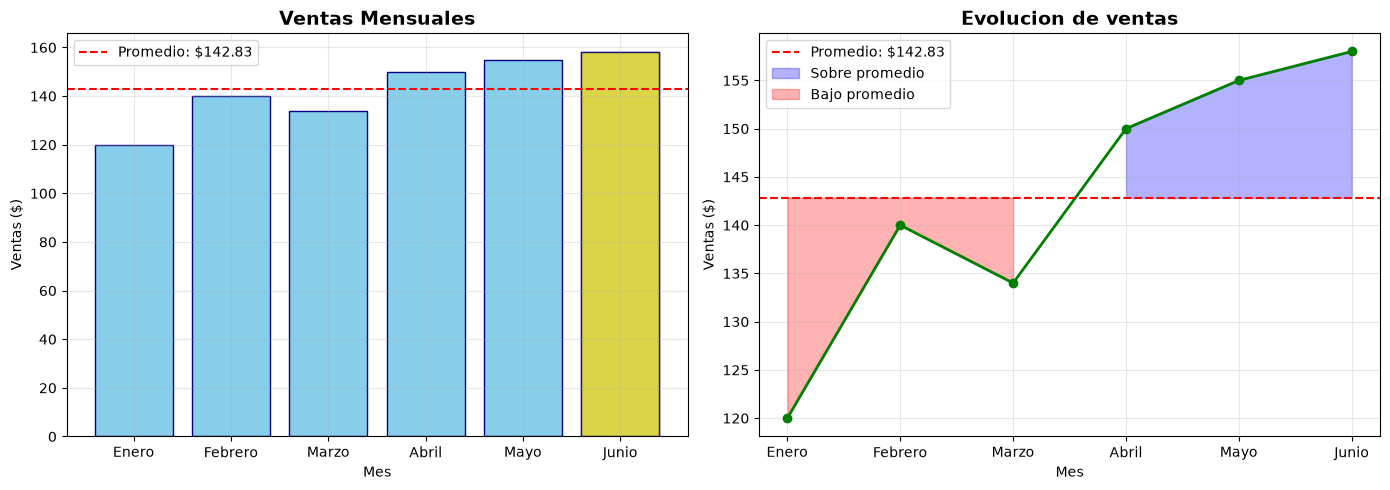

In [31]:
# Grafico de  barras
# visualizacion de los datos
fig, axes = plt.subplots(1,2,figsize=(14,5))

axes[0].bar(df['Mes'],df['Ventas'],color='skyblue',edgecolor='navy')
axes[0].axhline(y=promedio, color='red', linestyle='--', label=f'Promedio: ${promedio:.2f}')
axes[0].set_title('Ventas Mensuales', fontsize=14,fontweight='bold')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Ventas ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# destacar el mes con mayor venta
axes[0].bar(df.loc[df['Ventas'].idxmax(), 'Mes'],
            df['Ventas'].max(),
            color='gold',
            edgecolor='navy',
            alpha=0.7)

# grafico lineas
axes[1].plot(df['Mes'],df['Ventas'],marker='o', linewidth=2, color='green')
axes[1].axhline(y=promedio, color='red', linestyle='--', label=f'Promedio: ${promedio:.2f}')
axes[1].fill_between(df['Mes'],df['Ventas'], promedio,
                     where=(df['Ventas'] > promedio),
                     color='blue', alpha=0.3, label='Sobre promedio')
axes[1].fill_between(df['Mes'],df['Ventas'], promedio,
                     where=(df['Ventas'] <= promedio),
                     color='red', alpha=0.3, label='Bajo promedio')
axes[1].set_title('Evolucion de ventas', fontsize=14,fontweight='bold')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Ventas ($)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
